In [1]:
!pip install requests pandas matplotlib seaborn scikit-learn

import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
def load_data_from_api():

    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming?limit=50"

    os.makedirs("data", exist_ok=True)

    response = requests.get(url)
    response.raise_for_status()

    data = response.json()

    with open("data/launches.json", "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    df = pd.json_normalize(data["results"])

    print("총 데이터 개수:", len(df))
    print(df.head())

    return df


df = load_data_from_api()

총 데이터 개수: 50
                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url  launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...                NaN   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...                NaN   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...                NaN   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...                NaN   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...                NaN   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4          long-march-6a-unknown-payload   

            

In [3]:
def get_pictures():

    os.makedirs("images", exist_ok=True)

    with open("data/launches.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    launches = data["results"]

    for i, launch in enumerate(launches[:50]):

        image_url = launch.get("image")

        if not image_url:
            print(f"{i}번째 이미지 없음")
            continue

        try:
            response = requests.get(image_url, timeout=10)
            response.raise_for_status()

            file_path = f"images/launch_{i}.jpg"

            with open(file_path, "wb") as f:
                f.write(response.content)

            print(f"다운로드 완료: {file_path}")

        except requests.exceptions.RequestException as e:
            print(f"다운로드 실패: {image_url}")
            print(e)


get_pictures()

다운로드 완료: images/launch_0.jpg
다운로드 완료: images/launch_1.jpg
다운로드 완료: images/launch_2.jpg
다운로드 완료: images/launch_3.jpg
다운로드 완료: images/launch_4.jpg
다운로드 완료: images/launch_5.jpg
다운로드 완료: images/launch_6.jpg
다운로드 완료: images/launch_7.jpg
다운로드 완료: images/launch_8.jpg
다운로드 완료: images/launch_9.jpg
다운로드 완료: images/launch_10.jpg
다운로드 완료: images/launch_11.jpg
다운로드 완료: images/launch_12.jpg
다운로드 완료: images/launch_13.jpg
다운로드 완료: images/launch_14.jpg
다운로드 완료: images/launch_15.jpg
다운로드 완료: images/launch_16.jpg
다운로드 완료: images/launch_17.jpg
다운로드 완료: images/launch_18.jpg
다운로드 완료: images/launch_19.jpg
다운로드 완료: images/launch_20.jpg
다운로드 완료: images/launch_21.jpg
다운로드 완료: images/launch_22.jpg
다운로드 완료: images/launch_23.jpg
다운로드 완료: images/launch_24.jpg
다운로드 완료: images/launch_25.jpg
다운로드 완료: images/launch_26.jpg
다운로드 완료: images/launch_27.jpg
다운로드 완료: images/launch_28.jpg
다운로드 완료: images/launch_29.jpg
30번째 이미지 없음
다운로드 완료: images/launch_31.jpg
다운로드 완료: images/launch_32.jpg
다운로드 완료: images/launch_33.jpg
다운로드 완료:

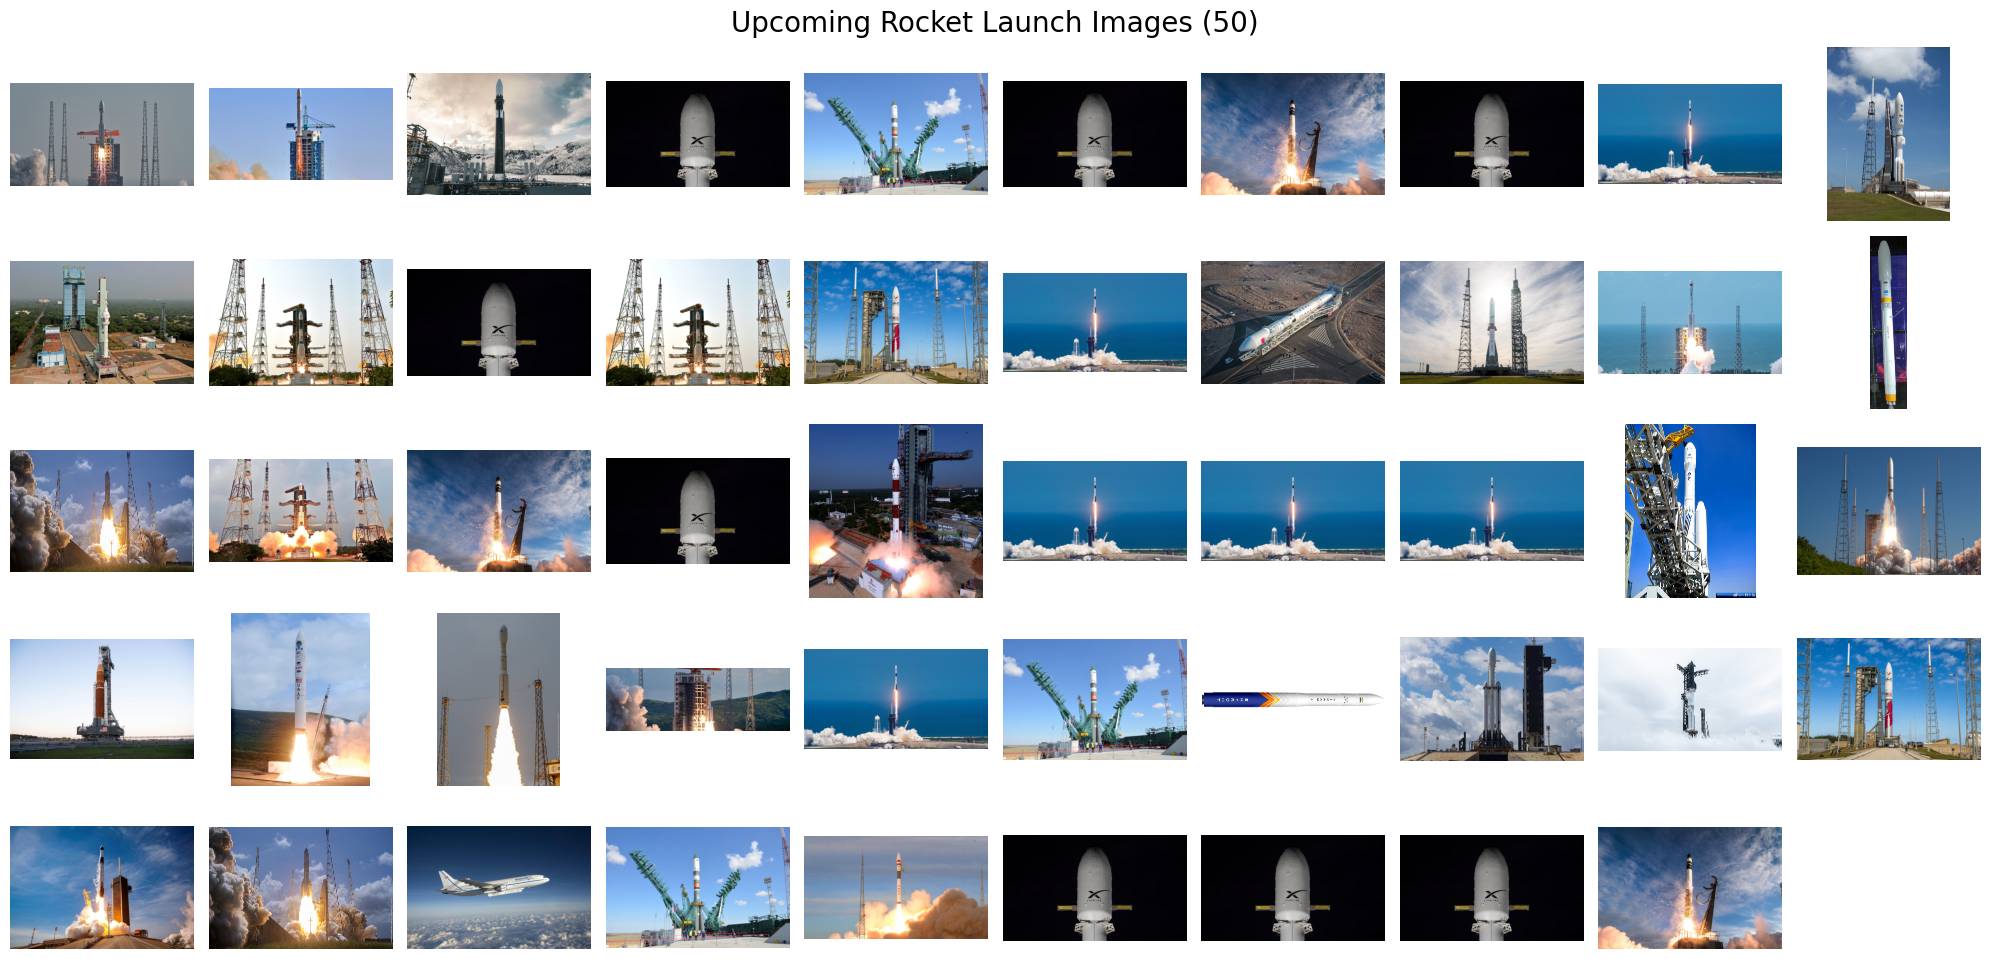

In [4]:
def visualize_images():

    image_folder = "images"
    image_files = sorted(os.listdir(image_folder))[:50]

    plt.figure(figsize=(20,10))

    for i, img_file in enumerate(image_files):

        img_path = os.path.join(image_folder, img_file)
        img = mpimg.imread(img_path)

        plt.subplot(5,10,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle("Upcoming Rocket Launch Images (50)", fontsize=20)
    plt.tight_layout()
    plt.show()


visualize_images()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


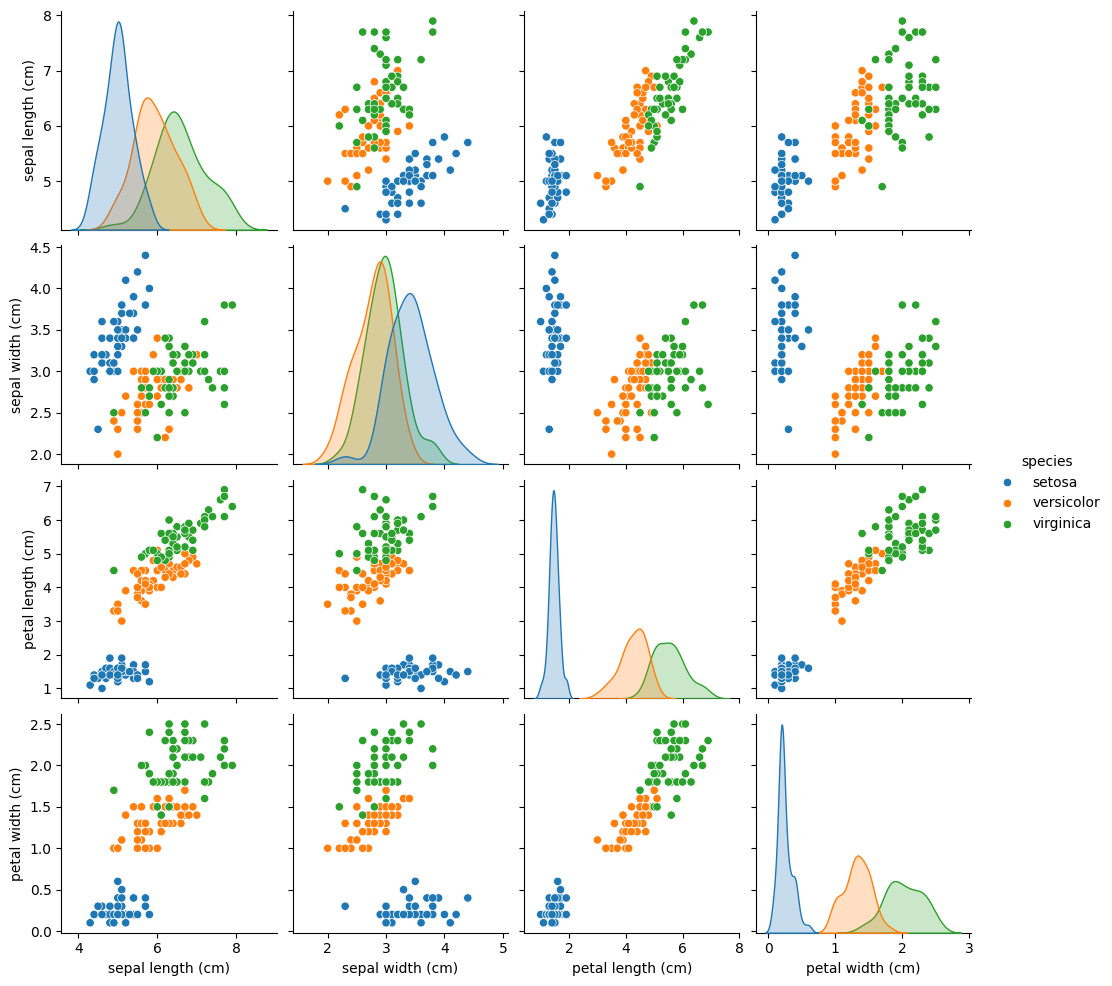

In [5]:
def iris_etl():

    # Extract
    iris = load_iris()

    # Transform
    df = pd.DataFrame(iris.data, columns=iris.feature_names)

    df["species"] = iris.target

    df["species"] = df["species"].map({
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    })

    # Load
    os.makedirs("data", exist_ok=True)
    df.to_csv("data/iris_dataset.csv", index=False)

    print(df.head())

    # Visualization
    sns.pairplot(df, hue="species")
    plt.show()


iris_etl()

In [6]:
for root, dirs, files in os.walk("."):
    level = root.replace(".", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

./
    .config/
        hidden_gcloud_config_universe_descriptor_data_cache_configs.db
        .last_opt_in_prompt.yaml
        .last_survey_prompt.yaml
        config_sentinel
        active_config
        gce
        default_configs.db
        .last_update_check.json
        configurations/
            config_default
        logs/
            2026.01.16/
                14.24.03.314209.log
                14.24.29.392089.log
                14.24.28.646070.log
                14.23.31.981136.log
                14.24.18.954466.log
                14.24.13.071214.log
    data/
        iris_dataset.csv
        launches.json
    images/
        launch_31.jpg
        launch_34.jpg
        launch_16.jpg
        launch_23.jpg
        launch_27.jpg
        launch_29.jpg
        launch_6.jpg
        launch_49.jpg
        launch_26.jpg
        launch_19.jpg
        launch_11.jpg
        launch_42.jpg
        launch_48.jpg
        launch_37.jpg
        launch_35.jpg
        launch_25.jpg
     